In [1]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path

#from osgeo import gdal, osr, gdalconst, gdal_array

In [2]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=8, g=18, r=28):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    im = ax.imshow(img)  # 画像を表示
    plt.show()
    
#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

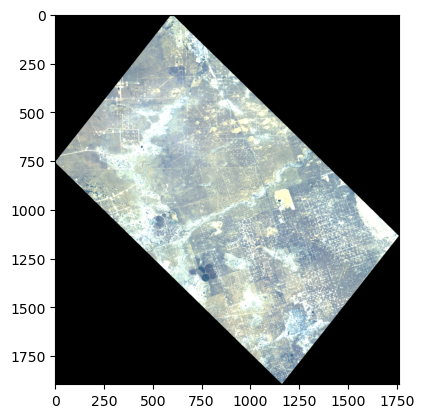

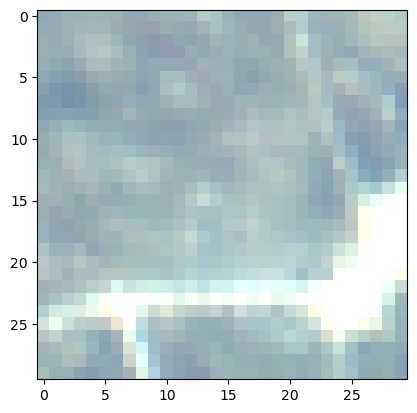

In [3]:
file = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.tif"

directory = r"E:\permian_basin\out_prof_ch4"
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1200, 800]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 15 : center[0] + 15, center[1] -15 : center[1] + 15, :] #補正後の画像
ims_slice = ims[center[0] - 15 : center[0] + 15, center[1] -15 : center[1] + 15 , :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

In [4]:
csv_path = Path(r"E:\permian_basin\out_prof_ch4\ch_h2ostr_merged_avg_170_180.csv")

# 読み込み（列: Waveln, 1.60, 1.65, ..., 2.00）
df = pd.read_csv(csv_path)

# 先頭列=波長, 残り=各濃度 → instrumental_function が期待する
# 形式（先頭行が波長ベクトル）に並べ替え
waves = df.iloc[:, 0].to_numpy(dtype=float)                 # (N_waves,)
vals  = df.iloc[:, 1:].to_numpy(dtype=float).T              # (N_levels, N_waves)

# data_co2: 先頭行が波長、以降が各濃度のスペクトル
data_ch4 = np.vstack([waves[np.newaxis, :], vals])          # (1 + N_levels, N_waves)
print(data_ch4)

[[3.80000e+02 3.81000e+02 3.82000e+02 ... 2.49800e+03 2.49900e+03
  2.50000e+03]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.03097e-01 5.43152e-01
  4.50556e-01]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.03064e-01 5.43002e-01
  4.50523e-01]
 ...
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.02899e-01 5.42256e-01
  4.50362e-01]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.02866e-01 5.42107e-01
  4.50329e-01]
 [4.00039e+02 4.70082e+02 3.84613e+02 ... 3.02833e-01 5.41958e-01
  4.50297e-01]]


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import least_squares

# --------------------------------------------------------------------------
# ▼▼▼ この部分にご自身のデータ読み込み処理を記述してください ▼▼▼
# --------------------------------------------------------------------------

# 1. MODTRANのメタンデータを読み込む
csv_path = Path(r"E:\permian_basin\out_prof_ch4\ch_h2ostr_merged_avg_170_180.csv")
df_ch4 = pd.read_csv(csv_path)
waves = df_ch4.iloc[:, 0].to_numpy(dtype=float)
vals = df_ch4.iloc[:, 1:].to_numpy(dtype=float).T
data_ch4 = np.vstack([waves[np.newaxis, :], vals])

# 2. HISUIの画像データやパラメータを読み込む（get_radianceで使うもの）
# (例)
# img_slice_pooling = ...
# param = ...

# 
img_slice_pooling = img[center[0] - 15 : center[0] + 15, center[1] -15 : center[1] + 15, :]
# --------------------------------------------------------------------------
# ▲▲▲ ここまでがデータ読み込み部分です ▲▲▲
# --------------------------------------------------------------------------
H, W, C = img_slice_pooling.shape
out_ch4 = np.empty((H, W, 1))
# --------------------------------------------------------------------------
# 共通の関数（変更なし）
# --------------------------------------------------------------------------
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import least_squares

# --------------------------------------------------------------------------
# ▼ 1. MODTRANデータ読み込み ▼
# --------------------------------------------------------------------------

# (ファイルパスはご自身の環境に合わせて修正してください)
csv_path = Path(r"E:\permian_basin\out_prof_ch4\ch_h2ostr_merged_avg_170_180.csv")
df_ch4 = pd.read_csv(csv_path)
waves = df_ch4.iloc[:, 0].to_numpy(dtype=float)
vals = df_ch4.iloc[:, 1:].to_numpy(dtype=float).T
data_ch4 = np.vstack([waves[np.newaxis, :], vals])

# --------------------------------------------------------------------------
# ▼ 2. 関数定義 (この部分は変更不要です) ▼
# --------------------------------------------------------------------------

def instrumental_function(data, sigma, mu):
    """装置関数を畳み込む"""
    column, row = data.shape
    x = data[0, :]
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode="same")
    return out

def reflectance_correction(data, a, b, k):
    """反射率を一次関数で補正する"""
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data

def extract_ch4(data):
    """MODTRANデータからメタンの吸収帯の範囲を抽出する"""
    return data[:, 1868:1918]

def estimated_by_methane(data, c):
    """メタン濃度を線形補間で推定する"""
    concentrations = np.arange(1.60, 1.60 + 0.05 * (data.shape[0] - 1), 0.05)
    position = np.searchsorted(concentrations, c)
    position = np.clip(position, 1, len(concentrations) - 1)
    
    out = []
    spectra_data = data[1:, :]
    for i in range(spectra_data.shape[1]):
        r = (c - concentrations[position - 1]) / 0.05
        interpolated_value = (1 - r) * spectra_data[position - 1, i] + r * spectra_data[position, i]
        out.append(interpolated_value)
    return out

def wavelength_adjustment_ch4(data_methane, modtran_wavelengths, data_hisui):
    """HISUIの波長にMODTRANのデータを線形補間する"""
    out = []
    for i in range(107, 113):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        
        if position == 0: position = 1
        if position >= len(modtran_wavelengths): position = len(modtran_wavelengths) - 1
        
        wave_width = modtran_wavelengths[position] - modtran_wavelengths[position-1]
        r = (hisui_wave - modtran_wavelengths[position - 1]) / wave_width if wave_width > 0 else 0
        interpolated_value = (1 - r) * data_methane[position - 1] + r * data_methane[position]
        out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    """メタン濃度からHISUIの輝度値をシミュレートする目的関数"""
    out = instrumental_function(data, sigma, mu)
    out = extract_ch4(out)
    modtran_wavelengths = out[0, :]
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_methane(out, c)
    out = wavelength_adjustment_ch4(out, modtran_wavelengths, data_hisui)
    return out

def residuals_ch4(param, data, data_hisui):
    """残差を計算する関数"""
    sigma, mu, a, b, c, k = param
    c_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
    return data_hisui.iloc[107:113, 1] - c_est

def estimate_param_ch4(data, data_hisui):
    """反射率補正の係数a, bの初期値を推定する"""
    out = instrumental_function(data, sigma=2.5, mu=0.0)
    out = extract_ch4(out)
    modtran_wavelengths = out[0, :]
    out = estimated_by_methane(out, c=1.8)
    out = wavelength_adjustment_ch4(out, modtran_wavelengths, data_hisui)
    out = np.array(out)
    
    highlight_points = [0, 1, 4, 5] 
    x = data_hisui.iloc[107:113, 0].iloc[highlight_points]
    y = data_hisui.iloc[107:113, 1].iloc[highlight_points] / out[highlight_points]
    
    coefficients = np.polyfit(x, y, 1)
    return coefficients # [0]が傾きb, [1]が切片a

# --------------------------------------------------------------------------
# ▼ 3. メインの処理ループ ▼
# --------------------------------------------------------------------------

# 【！】ご自身のHISUI画像データと、ピクセル値取得関数をここで定義してください
# 例：
# img_slice_pooling = ...  # 画像データをロード
# param = ...              # get_radianceで使うパラメータ
# def get_radiance(img, p, y, x):
#     # ...ピクセル(y,x)のスペクトルを返す処理...
#     return spectral_data

# 画像サイズから高さ(H)と幅(W)を取得し、結果格納用の配列を初期化
H, W, C = img_slice_pooling.shape
out_ch4 = np.empty((H, W, 1))

print("メタン濃度推定処理を開始します...")

for y in range(H):
    for x in range(W):
        # HISUIの1ピクセル分のスペクトルデータを取得する
        data_rad = get_radiance(img_slice_pooling, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

        # 以下が1ピクセルあたりの計算処理
        if np.max(df.iloc[:, 1]) == 0:
            estimated_methane = 0
        else:
            # 初期値を推定
            b, a = estimate_param_ch4(data_ch4, df)
            initial_params = np.array([2.5, 0.0, a, b, 1.8, 0.0])
            
            # 最小二乗法を実行 ('lm'メソッドを使用)
            res = least_squares(
                residuals_ch4,
                initial_params,
                args=(data_ch4, df),
                method="lm"
            )
            
            estimated_methane = res.x[4]

            # 【重要】結果がMODTRANデータの範囲内かチェック
            if not (1.6 <= estimated_methane <= 2.0):
                print(f"警告: ピクセル(y={y}, x={x})で信頼区間外の値が算出されました: {estimated_methane:.4f} ppm")
                # 範囲外の値を無効な値（NaNなど）として記録することもできます
                # estimated_methane = np.nan 

        # 結果を保存
        out_ch4[y, x, :] = estimated_methane
    
    # 進捗表示 (10行ごと)
    if (y + 1) % 10 == 0:
        print(f"進捗: {y + 1} / {H} 行完了")

print("全てのピクセルの処理が完了しました。")

メタン濃度推定処理を開始します...
警告: ピクセル(y=0, x=0)で信頼区間外の値が算出されました: -0.4838 ppm
警告: ピクセル(y=0, x=1)で信頼区間外の値が算出されました: -0.3136 ppm
警告: ピクセル(y=0, x=2)で信頼区間外の値が算出されました: -0.1908 ppm
警告: ピクセル(y=0, x=3)で信頼区間外の値が算出されました: 0.1042 ppm


IndexError: index 9 is out of bounds for axis 0 with size 9

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import least_squares

# --------------------------------------------------------------------------
# ▼ 1. MODTRANデータ読み込み ▼
# --------------------------------------------------------------------------

# (ファイルパスはご自身の環境に合わせて修正してください)
csv_path = Path(r"E:\permian_basin\out_prof_ch4\ch_h2ostr_merged_avg_170_180.csv")
df_ch4 = pd.read_csv(csv_path)
waves = df_ch4.iloc[:, 0].to_numpy(dtype=float)
vals = df_ch4.iloc[:, 1:].to_numpy(dtype=float).T
data_ch4 = np.vstack([waves[np.newaxis, :], vals])

# --------------------------------------------------------------------------
# ▼ 2. 関数定義 ▼
# --------------------------------------------------------------------------

def instrumental_function(data, sigma, mu):
    """装置関数を畳み込む"""
    column, row = data.shape
    x = data[0, :]
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode="same")
    return out

def reflectance_correction(data, a, b, k):
    """反射率を一次関数で補正する"""
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data

def extract_ch4(data):
    """MODTRANデータからメタンの吸収帯の範囲を抽出する"""
    return data[:, 1868:1918]

# ▼▼▼【修正箇所】エラーを修正し、高速化した関数 ▼▼▼
def estimated_by_methane(data, c):
    """
    メタン濃度を線形補間/外挿で推定する。
    最適化中にcが範囲外になってもエラーを起こさない安定版。
    """
    concentrations = 1.60 + 0.05 * np.arange(data.shape[0] - 1)
    spectra_data = data[1:, :] # ← 正しくスペクトルデータのみを抽出
    num_levels = len(concentrations)
    
    position = np.searchsorted(concentrations, c)
    
    # positionをクリップして、安全に外挿できるようにする
    if position < 1:
        position = 1
    if position >= num_levels:
        position = num_levels - 1
        
    # これでインデックスは常に安全
    r = (c - concentrations[position - 1]) / 0.05
    interpolated_spectrum = (1 - r) * spectra_data[position - 1, :] + r * spectra_data[position, :]
    
    return interpolated_spectrum.tolist()

def wavelength_adjustment_ch4(data_methane, modtran_wavelengths, data_hisui):
    """HISUIの波長にMODTRANのデータを線形補間する"""
    out = []
    for i in range(107, 113):
        hisui_wave = data_hisui.iloc[i, 0]
        position = np.searchsorted(modtran_wavelengths, hisui_wave)
        
        if position == 0: position = 1
        if position >= len(modtran_wavelengths): position = len(modtran_wavelengths) - 1
        
        wave_width = modtran_wavelengths[position] - modtran_wavelengths[position-1]
        r = (hisui_wave - modtran_wavelengths[position - 1]) / wave_width if wave_width > 0 else 0
        interpolated_value = (1 - r) * data_methane[position - 1] + r * data_methane[position]
        out.append(interpolated_value)
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    """メタン濃度からHISUIの輝度値をシミュレートする目的関数"""
    out = instrumental_function(data, sigma, mu)
    out = extract_ch4(out)
    modtran_wavelengths = out[0, :]
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_methane(out, c)
    out = wavelength_adjustment_ch4(out, modtran_wavelengths, data_hisui)
    return out

def residuals_ch4(param, data, data_hisui):
    """残差を計算する関数"""
    sigma, mu, a, b, c, k = param
    c_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
    return data_hisui.iloc[107:113, 1] - c_est

def estimate_param_ch4(data, data_hisui):
    """反射率補正の係数a, bの初期値を推定する"""
    out = instrumental_function(data, sigma=2.5, mu=0.0)
    out = extract_ch4(out)
    modtran_wavelengths = out[0, :]
    out = estimated_by_methane(out, c=1.8)
    out = wavelength_adjustment_ch4(out, modtran_wavelengths, data_hisui)
    out = np.array(out)
    
    highlight_points = [0, 1, 4, 5] 
    x = data_hisui.iloc[107:113, 0].iloc[highlight_points]
    y = data_hisui.iloc[107:113, 1].iloc[highlight_points] / out[highlight_points]
    
    coefficients = np.polyfit(x, y, 1)
    return coefficients

# --------------------------------------------------------------------------
# ▼ 3. メインの処理ループ ▼
# --------------------------------------------------------------------------

# 【！】ご自身のHISUI画像データと、ピクセル値取得関数をここで定義してください
# 例：
# img_slice_pooling = ...  # 画像データをロード
# param = ...              # get_radianceで使うパラメータ
# def get_radiance(img, p, y, x):
#     # ...ピクセル(y,x)のスペクトルを返す処理...
#     return spectral_data

# 画像サイズから高さ(H)と幅(W)を取得し、結果格納用の配列を初期化
H, W, C = img_slice_pooling.shape
out_ch4 = np.empty((H, W, 1))

print("メタン濃度推定処理を開始します...")

for y in range(H):
    for x in range(W):
        # HISUIの1ピクセル分のスペクトルデータを取得する
        data_rad = get_radiance(img_slice_pooling, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

        if np.max(df.iloc[:, 1]) == 0:
            estimated_methane = 0
        else:
            b, a = estimate_param_ch4(data_ch4, df)
            initial_params = np.array([2.5, 0.0, a, b, 1.8, 0.0])
            
            res = least_squares(
                residuals_ch4,
                initial_params,
                args=(data_ch4, df),
                method="lm"
            )
            
            estimated_methane = res.x[4]

            if not (1.6 <= estimated_methane <= 2.0):
                print(f"警告: ピクセル(y={y}, x={x})で信頼区間外の値が算出されました: {estimated_methane:.4f} ppm")
                # estimated_methane = np.nan 

        out_ch4[y, x, :] = estimated_methane
    
    if (y + 1) % 10 == 0:
        print(f"進捗: {y + 1} / {H} 行完了")

print("全てのピクセルの処理が完了しました。")

メタン濃度推定処理を開始します...
警告: ピクセル(y=0, x=0)で信頼区間外の値が算出されました: -0.4845 ppm
警告: ピクセル(y=0, x=1)で信頼区間外の値が算出されました: -0.3120 ppm
警告: ピクセル(y=0, x=2)で信頼区間外の値が算出されました: -0.0302 ppm
警告: ピクセル(y=0, x=3)で信頼区間外の値が算出されました: 0.1043 ppm
警告: ピクセル(y=0, x=4)で信頼区間外の値が算出されました: 4.9623 ppm
警告: ピクセル(y=0, x=5)で信頼区間外の値が算出されました: 0.5559 ppm
警告: ピクセル(y=0, x=6)で信頼区間外の値が算出されました: 0.4091 ppm
警告: ピクセル(y=0, x=7)で信頼区間外の値が算出されました: 0.9639 ppm
警告: ピクセル(y=0, x=8)で信頼区間外の値が算出されました: 0.6868 ppm
警告: ピクセル(y=0, x=9)で信頼区間外の値が算出されました: 0.6178 ppm
警告: ピクセル(y=0, x=10)で信頼区間外の値が算出されました: -0.3850 ppm
警告: ピクセル(y=0, x=11)で信頼区間外の値が算出されました: 0.4098 ppm
警告: ピクセル(y=0, x=12)で信頼区間外の値が算出されました: 1.4410 ppm
警告: ピクセル(y=0, x=13)で信頼区間外の値が算出されました: 1.1431 ppm
警告: ピクセル(y=0, x=14)で信頼区間外の値が算出されました: 0.3987 ppm
警告: ピクセル(y=0, x=15)で信頼区間外の値が算出されました: -0.1914 ppm
警告: ピクセル(y=0, x=16)で信頼区間外の値が算出されました: -0.2374 ppm
警告: ピクセル(y=0, x=17)で信頼区間外の値が算出されました: 0.8861 ppm
警告: ピクセル(y=0, x=18)で信頼区間外の値が算出されました: 0.8373 ppm
警告: ピクセル(y=0, x=19)で信頼区間外の値が算出されました: -0.0087 ppm
警告: ピクセル(y=0, x=20)で信頼区間

KeyboardInterrupt: 